In [9]:
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [10]:
etf_dict = {
    'Large Cap': [ 'IVV'],
    'Small Cap': [ 'SCHA'],
    'EM Equity': [ 'IEMG'],
    'DM Equity': [ 'SCHF'],
    'REITs': ['VNQ',],
    'High Yield': ['HYG'],
    'Fixed Income': ['BND'],
    'Commodities': ['DBC', ],
    'Cash': ['BIL']
}

In [11]:
list(etf_dict.values())

[['IVV'],
 ['SCHA'],
 ['IEMG'],
 ['SCHF'],
 ['VNQ'],
 ['HYG'],
 ['BND'],
 ['DBC'],
 ['BIL']]

In [19]:
price = yf.download(tickers=['IVV',
 'SCHA',
 'IEMG',
 'SCHF',
 'VNQ',
 'HYG',
 'BND',
 'DBC',
 'BIL'], period='20y', interval='1d')['Close'].dropna()

[*********************100%***********************]  9 of 9 completed


In [20]:
ticker_to_class = {
    ticker: asset_class
    for asset_class, tickers in etf_dict.items()
    for ticker in tickers
}

price.columns = price.columns.map(ticker_to_class)
price['P'] = price.index.to_period('Y')

retornos = price.groupby('P').last()/price.groupby('P').first() - 1
df = retornos.T

In [21]:
df

P,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Ticker,,,,,,,,,,,,,,,
Cash,-0.000219,-0.000873,-0.000656,-0.001094,0.000876,0.006452,0.017262,0.020431,0.003656,-0.000983,0.014157,0.049334,0.051815,0.041244,0.009457
Fixed Income,-0.006073,-0.019557,0.057254,0.002184,0.025723,0.039866,0.003990,0.086145,0.075739,-0.017273,-0.125238,0.050985,0.018117,0.070377,0.008974
Commodities,0.012022,-0.079627,-0.270463,-0.267142,0.194570,0.061342,-0.120539,0.115314,-0.079524,0.421341,0.188822,-0.038942,0.030257,0.070521,0.287628
High Yield,0.019491,0.047659,0.017189,-0.050214,0.140940,0.056345,-0.021139,0.142436,0.040298,0.039705,-0.109419,0.113298,0.083300,0.083305,0.012506
EM Equity,0.085099,-0.047107,0.000884,-0.134940,0.131549,0.359044,-0.165356,0.175390,0.154792,-0.014329,-0.204450,0.106480,0.078398,0.327923,0.105725
Large Cap,0.017425,0.291573,0.145804,0.013525,0.131252,0.208996,-0.051950,0.311944,0.172799,0.305563,-0.186474,0.268606,0.256546,0.180932,0.019408
Small Cap,0.049122,0.357294,0.074882,-0.038994,0.223135,0.141590,-0.125895,0.260441,0.191859,0.180733,-0.206296,0.191412,0.118492,0.116415,0.093087
DM Equity,0.073258,0.171381,-0.039431,-0.021139,0.046981,0.251252,-0.148869,0.226020,0.086081,0.106365,-0.153406,0.175837,0.043845,0.349863,0.092360
REITs,0.032564,0.010442,0.303788,0.009126,0.098969,0.045569,-0.056745,0.317735,-0.034766,0.452575,-0.256681,0.117435,0.039179,0.041694,0.075828


C:\Users\F000333\AppData\Local\Temp\ipykernel_34152\3293531498.py:84: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  wrapped_data = tabela_periodica.applymap(lambda x: wrap_text(str(x), 10))  # Ajustar o valor de largura conforme necessário


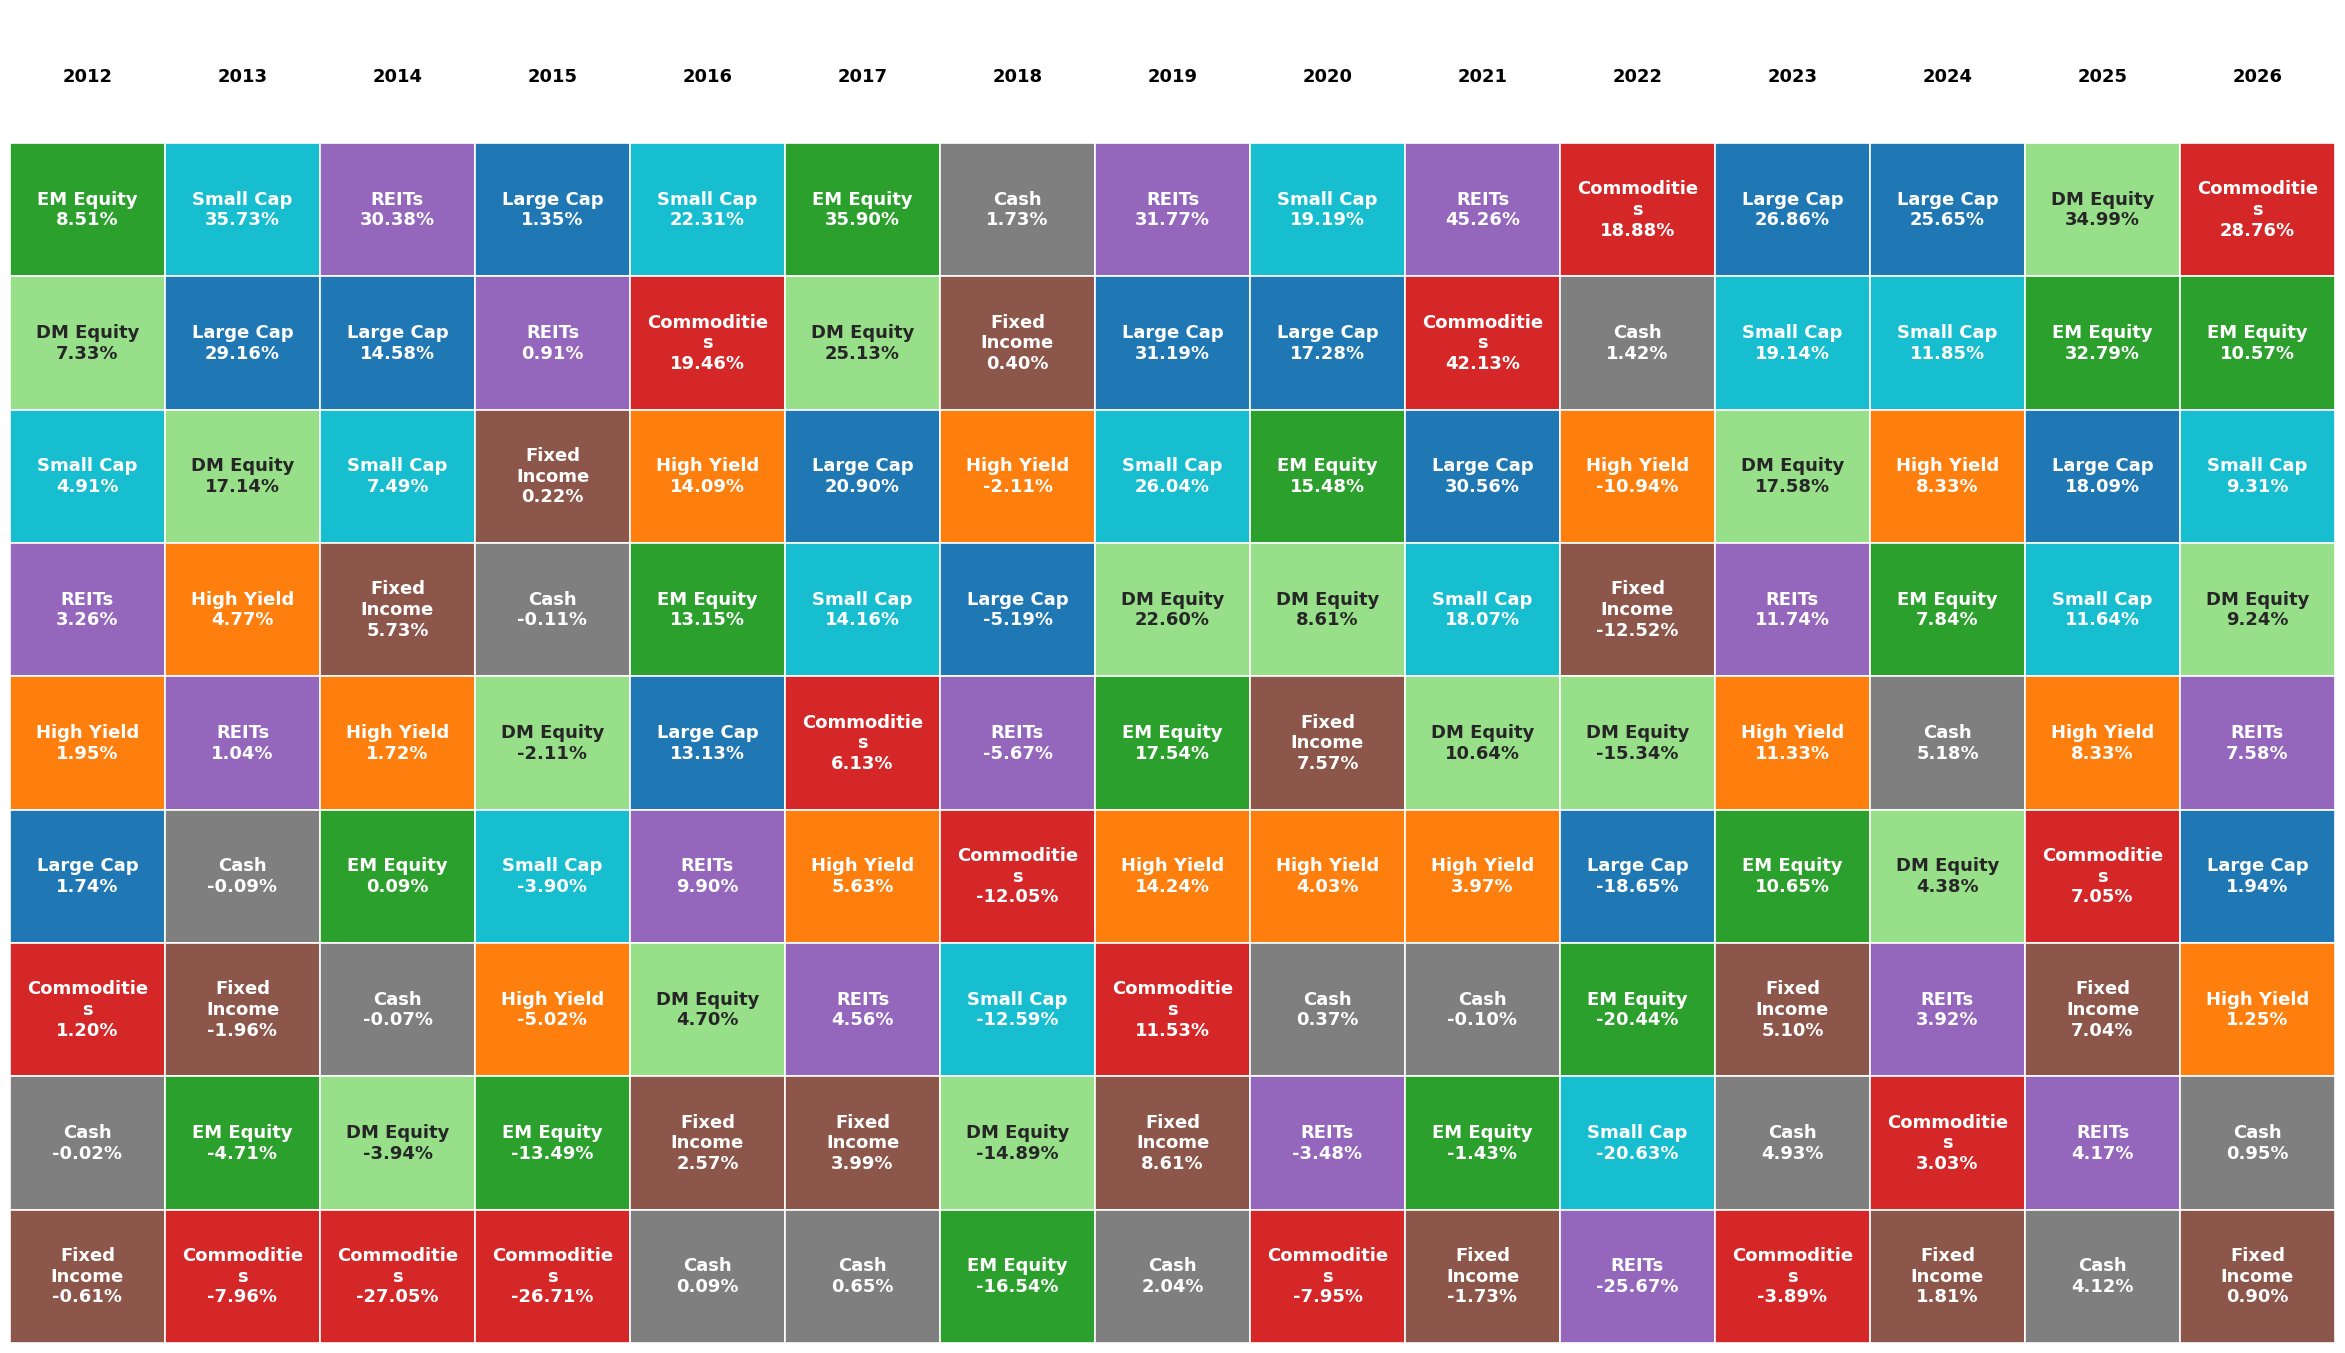

In [22]:
df.columns = pd.Series(df.columns.astype(str)).replace("NaT", "").values
df_nome = df.copy()

periodos = df.columns

colunas = []
for i in range(len(df_nome.columns)):
    temp = df_nome.iloc[:,i].sort_values(ascending=False)
    temp = pd.DataFrame(temp)
    temp =  temp.apply(lambda x: x.index + "                   " + x.apply(lambda y: f"{y:.2%}"))
    temp = temp.reset_index()
    temp = temp.iloc[:,1]
    colunas.append(temp)
    
tabela_periodica = pd.concat(colunas,ignore_index=True,axis=1)
tabela_periodica.columns = periodos




import matplotlib.pyplot as plt
import pandas as pd
import textwrap


#######################################################################################################
###################################!!!!PONTO IMPORTANTE!!!!############################################
########  AQUI É PRECISO ESCOLHER AS CORES E ESTILODE FONTE PARA CADA ATIVO############################
#######################################################################################################

# Definir as cores para cada classe
color_map = {
    'Large Cap':  "#1f77b4",  # Large Cap (azul clássico)
    'Small Cap': "#17becf",  # Small Cap (azul claro)
    'EM Equity': "#2ca02c",  # EM Equity (verde)
    'DM Equity': "#98df8a",  # DM Equity (verde claro)
    'REITs':  "#9467bd",  # REITs (roxo)
    'High Yield':  "#ff7f0e",  # High Yield (laranja)
    'Fixed Income':  "#8c564b",  # Fixed Income (marrom)
    'Commodities':  "#d62728",  # Commodities (vermelho)
    'Cash':  "#7f7f7f"   # Cash (cinza)
}
['Cash', 'Fixed Income', 'Commodities', 'High Yield', 'EM Equity',
       'Large Cap', 'Small Cap', 'DM Equity', 'REITs']

# Definir as cores da fonte
font_color_map = {
    'Large Cap':  "#FFFFFF",  # Large Cap (azul clássico)
    'Small Cap': "#FFFFFF",  # Small Cap (azul claro)
    'EM Equity': "#FFFFFF",  # EM Equity (verde)
    'DM Equity': "#262626",  # DM Equity (verde claro)
    'REITs':  "#FFFFFF",  # REITs (roxo)
    'High Yield':  "#FFFFFF",  # High Yield (laranja)
    'Fixed Income':  "#FFFFFF",  # Fixed Income (marrom)
    'Commodities':  "#FFFFFF",  # Commodities (vermelho)
    'Cash':  "#FFFFFF"  
}
# Definir o estilo da fonte
font_style_map = {
    'Large Cap':  "bold",  # Large Cap (azul clássico)
    'Small Cap': "bold",  # Small Cap (azul claro)
    'EM Equity': "bold",  # EM Equity (verde)
    'DM Equity': "bold",  # DM Equity (verde claro)
    'REITs':  "bold",  # REITs (roxo)
    'High Yield':  "bold",  # High Yield (laranja)
    'Fixed Income':  "bold",  # Fixed Income (marrom)
    'Commodities':  "bold",  # Commodities (vermelho)
    'Cash':  "bold" 
}
#######################################################################################################
#######################################################################################################


# Função para quebrar texto
def wrap_text(text, width):
    return '\n'.join(textwrap.wrap(text, width))

# Criar a tabela com matplotlib
fig, ax = plt.subplots(figsize=(10, 10)) # Ajustar o tamanho geral da tabela
ax.axis('tight')
ax.axis('off')

# Ajustar o texto nas células
wrapped_data = tabela_periodica.applymap(lambda x: wrap_text(str(x), 10))  # Ajustar o valor de largura conforme necessário

# Criar a tabela
table = ax.table(cellText=wrapped_data.values, colLabels=tabela_periodica.columns, cellLoc='center', loc='center')

# Ajustar o tamanho da fonte
table.auto_set_font_size(True)
table.set_fontsize(20)

# Ajustar manualmente a largura das colunas
col_widths =[0.2] * df_nome.shape[1]  # Defina a largura desejada para cada coluna
# col_widths[-3] = 0.01  # Ajustar a largura da coluna vazia' para ser menor


for key in table.get_celld().keys():
    row, col = key
    cell = table.get_celld()[(row, col)]
    if row == 0:  # Linha do cabeçalho
        cell.set_fontsize(18)
        cell.set_text_props(weight='bold')  # Definir o texto como negrito
        cell.set_edgecolor('white')
        cell.set_linewidth(1.2)
        txt = cell.get_text()
        txt.set_va('center')
        x, y = txt.get_position()
        txt.set_position((x, y - 0.25))
    if col < len(col_widths):  # Ignorar a linha do cabeçalho
        cell.set_width(col_widths[col])



# Colorir as células conforme o color_map e ajustar a fonte conforme font_color_map e font_style_map
for i, row in tabela_periodica.iterrows():
    for j, col in enumerate(tabela_periodica.columns):
        value = tabela_periodica.at[i, col]
        bg_color = 'white'  # Default background color
        font_color = 'black'  # Default font color
        font_weight = 'regular'  # Default font weight
        for key in color_map.keys():
            if key in str(value):  # Verificar substring
                bg_color = color_map[key]
                font_color = font_color_map[key]
                font_weight = font_style_map[key]
                break
        cell = table[(i+1, j)]
        cell.set_facecolor(bg_color)
        cell.set_text_props(color=font_color, weight=font_weight)
        cell.set_edgecolor('white')
        cell.set_linewidth(1.2)

# Ajustar altura das linhas
table.scale(1, 8)  # ajuste a altura das linhas (1.5 é um exemplo, ajuste conforme necessário)

# Ajustar layout
# plt.title('Tabela Rentabilidades ')
plt.savefig('Tabela Periodica USD.jpeg', format='jpeg',dpi=400)
plt.show()